# Decision Trees in Machine Learning
## TTK4260 — Multivariate Data Analysis & Machine Learning

**Adil Rasheed**

**Department of Engineering Cybernetics, NTNU**

---

This notebook accompanies the lecture on Decision Trees. It provides:

1. **Visual intuition** for how trees partition the feature space
2. **Hands-on derivation** of split criteria (Gini, entropy, RSS)
3. **Step-by-step tree building** from scratch
4. **Scikit-learn demonstrations** with real and synthetic data
5. **Bias–variance analysis** and the effect of depth
6. **Pruning and regularisation** experiments
7. **From single trees to ensembles** — bagging, random forests, and boosting

### Notation Convention
| Symbol | Meaning |
|--------|---------|
| $x_j$ (italic, non-bold) | scalar: the $j$-th feature value |
| $\boldsymbol{x}$ (italic, bold) | vector: a single observation |
| $\mathbf{X}$ (bold, non-italic) | matrix: the full design matrix |
| $n$ | number of features (dimensionality) |
| $m$ | number of samples |
| $y$ | dependent / response variable |


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    BaggingRegressor
)
from sklearn.datasets import make_moons, make_classification, load_iris
from sklearn.model_selection import train_test_split, cross_val_score, validation_curve
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.inspection import DecisionBoundaryDisplay
import warnings
warnings.filterwarnings('ignore')

# ── NTNU colour palette ──
NTNU = {
    'blue':   '#00509E',
    'light':  '#E6F2FF',
    'teal':   '#00A896',
    'orange': '#E67700',
    'green':  '#009444',
    'red':    '#C83232',
    'purple': '#6F3198',
    'gray':   '#6B7D8E',
}

# ── Global plot style ──
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#FAFBFD',
    'axes.edgecolor':   '#D0D8E0',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.color':       '#C0C8D0',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'figure.dpi':       120,
    'figure.figsize':   (10, 5),
    'legend.fontsize':  10,
    'legend.framealpha': 0.9,
})

cmap_cls = ListedColormap([NTNU['blue'], NTNU['orange']])
cmap_cls3 = ListedColormap([NTNU['blue'], NTNU['orange'], NTNU['green']])

print("✓ Setup complete — NTNU palette loaded")


✓ Setup complete — NTNU palette loaded


---
## 1. Motivation: What Does a Decision Tree Do?

A decision tree recursively partitions the feature space into **axis-aligned regions** (hyperrectangles), then predicts a constant value within each region.

Let's see this visually with a simple 2D classification problem.


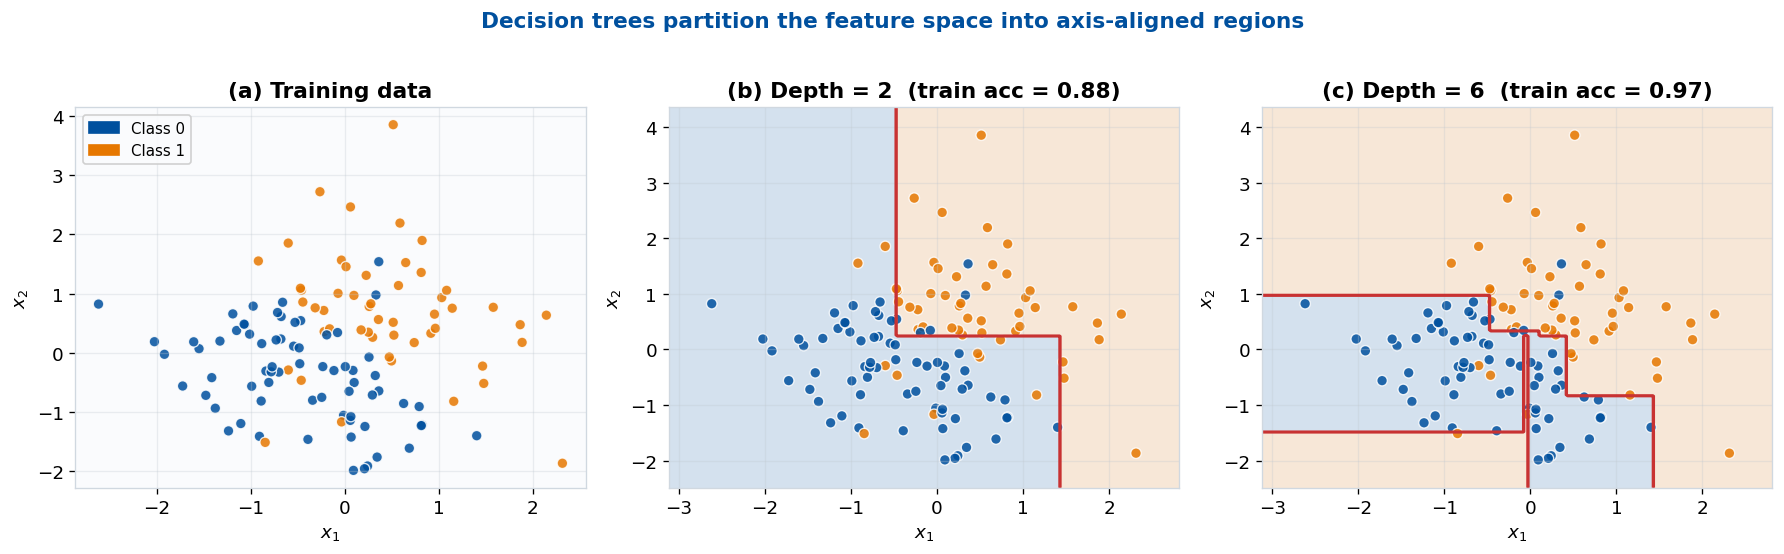

In [39]:
# ── Generate a simple 2D dataset ──
np.random.seed(42)
m = 120
X = np.random.randn(m, 2)
y = ((X[:, 0] + X[:, 1]) > 0.3).astype(int)
# Add a bit of noise
flip = np.random.choice(m, size=8, replace=False)
y[flip] = 1 - y[flip]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: Raw data ──
ax = axes[0]
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_cls, 
                     edgecolors='white', linewidth=0.8, s=40, alpha=0.85)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('(a) Training data')
ax.legend(handles=[
    mpatches.Patch(color=NTNU['blue'], label='Class 0'),
    mpatches.Patch(color=NTNU['orange'], label='Class 1')
], loc='upper left', fontsize=9)

# ── Panel 2: Shallow tree (depth 2) ──
for idx, depth in enumerate([2, 6]):
    ax = axes[idx + 1]
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X, y)
    
    # Decision boundary
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                         np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.15, cmap=cmap_cls, levels=1)
    ax.contour(xx, yy, Z, colors=NTNU['red'], linewidths=1.5, levels=1)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_cls, 
              edgecolors='white', linewidth=0.8, s=40, alpha=0.85)
    acc = accuracy_score(y, clf.predict(X))
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title(f'({"b" if depth==2 else "c"}) Depth = {depth}  (train acc = {acc:.2f})')

plt.suptitle('Decision trees partition the feature space into axis-aligned regions',
             fontsize=13, fontweight='bold', color=NTNU['blue'], y=1.02)
plt.tight_layout()
plt.show()


**Observations:**
- **(a)** The raw data has two classes with a roughly diagonal boundary.
- **(b)** A shallow tree (depth 2) captures the main trend but misses fine structure — **high bias**.
- **(c)** A deep tree (depth 6) fits the training data very well, but creates many small regions that may not generalise — **high variance**.

This is the **bias–variance tradeoff** in action, which we'll explore in detail later.


---
## 2. Anatomy of a Decision Tree

Let's train a simple tree on the Iris dataset and visualise its structure.


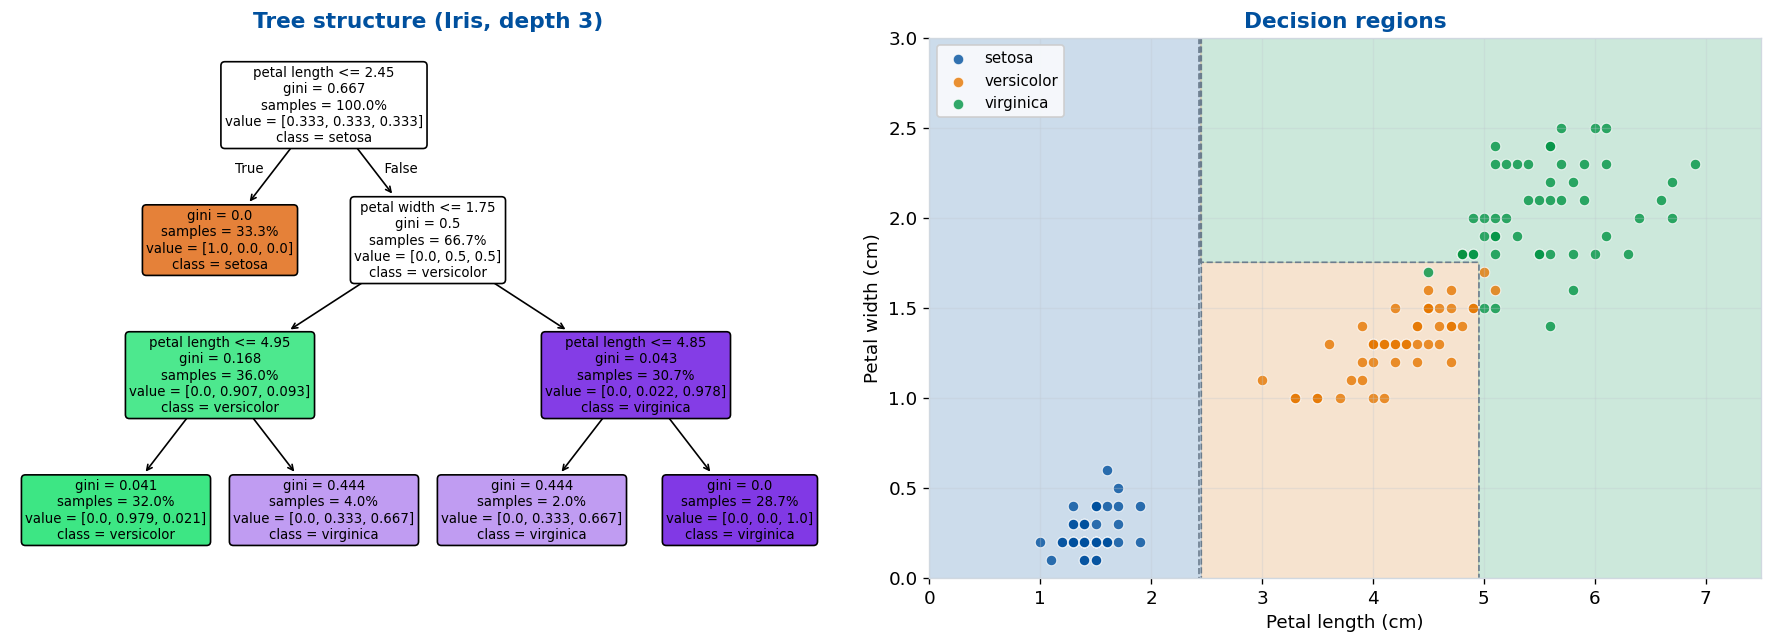

── Decision rules ──
|--- petal length <= 2.45
|   |--- class: setosa
|--- petal length >  2.45
|   |--- petal width <= 1.75
|   |   |--- petal length <= 4.95
|   |   |   |--- class: versicolor
|   |   |--- petal length >  4.95
|   |   |   |--- class: virginica
|   |--- petal width >  1.75
|   |   |--- petal length <= 4.85
|   |   |   |--- class: virginica
|   |   |--- petal length >  4.85
|   |   |   |--- class: virginica



In [40]:
# ── Iris dataset — classic 3-class problem ──
iris = load_iris()
X_iris = iris.data[:, [2, 3]]  # petal length, petal width
y_iris = iris.target
feature_names = ['petal length', 'petal width']

clf_iris = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_iris.fit(X_iris, y_iris)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Panel 1: Tree structure ──
ax = axes[0]
plot_tree(clf_iris, 
          feature_names=feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True,
          fontsize=8, ax=ax,
          impurity=True, proportion=True)
ax.set_title('Tree structure (Iris, depth 3)', color=NTNU['blue'])

# ── Panel 2: Decision regions ──
ax = axes[1]
xx, yy = np.meshgrid(np.linspace(0, 7.5, 300), np.linspace(0, 3, 300))
Z = clf_iris.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.18, cmap=cmap_cls3, levels=2)
ax.contour(xx, yy, Z, colors=NTNU['gray'], linewidths=1, levels=2, linestyles='--')

for k, (name, color) in enumerate(zip(iris.target_names, 
                                        [NTNU['blue'], NTNU['orange'], NTNU['green']])):
    mask = y_iris == k
    ax.scatter(X_iris[mask, 0], X_iris[mask, 1], c=color, label=name,
              edgecolors='white', linewidth=0.6, s=40, alpha=0.8)

ax.set_xlabel('Petal length (cm)')
ax.set_ylabel('Petal width (cm)')
ax.set_title('Decision regions', color=NTNU['blue'])
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# Print the rules
print("── Decision rules ──")
print(export_text(clf_iris, feature_names=feature_names, 
                  class_names=list(iris.target_names)))


**Key observations:**
- Each **internal node** tests a single feature against a threshold: $x_j < t$.
- Each **leaf** stores class proportions and a prediction.
- The tree partitions the 2D feature space into **rectangles** — you can see the axis-aligned boundaries in the right panel.
- Reading root → leaf gives a human-readable **IF-THEN rule**.


---
## 3. Split Criteria: Measuring Impurity

At each node, we need a **scalar measure of heterogeneity** to decide which split is best.

For binary classification with class probability $p$:

| Criterion | Formula |
|-----------|---------|
| Misclassification error | $1 - \max(p, 1-p)$ |
| Gini impurity | $2p(1-p)$ |
| Entropy | $-p\log_2 p - (1-p)\log_2(1-p)$ |


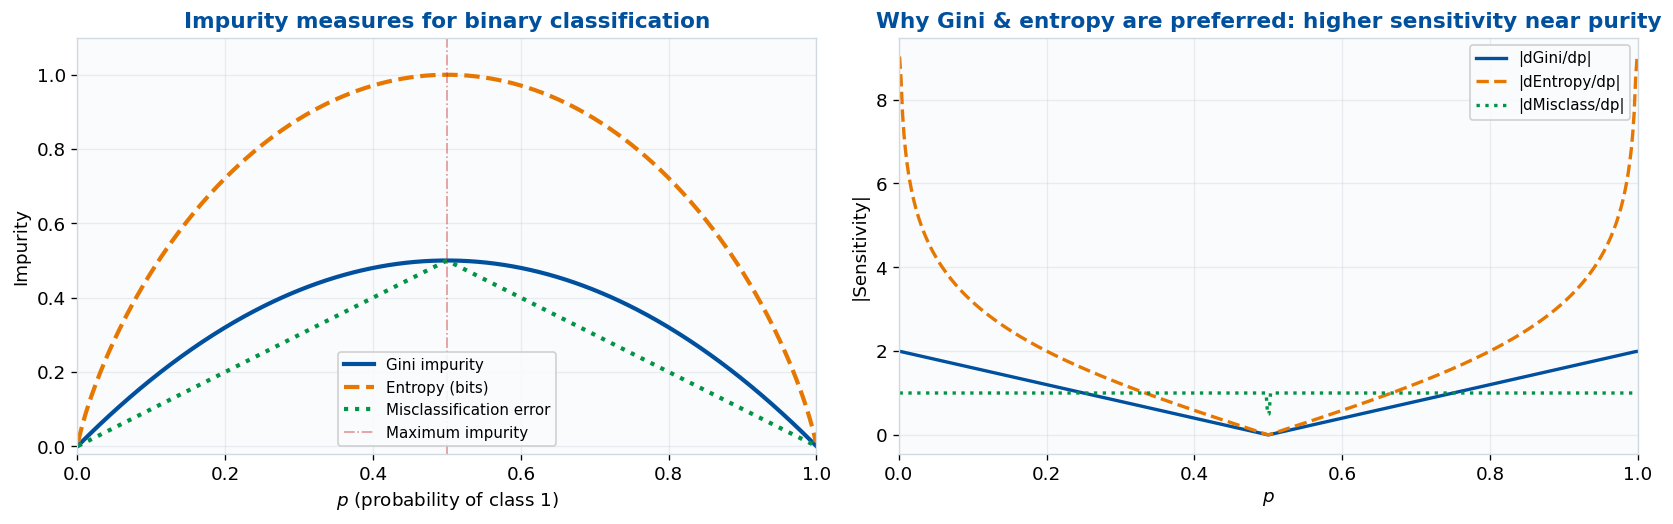

In [41]:
p = np.linspace(0.001, 0.999, 500)

gini    = 2 * p * (1 - p)
entropy = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
misclass = 1 - np.maximum(p, 1 - p)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# ── Panel 1: All three curves ──
ax = axes[0]
ax.plot(p, gini,     color=NTNU['blue'],   linewidth=2.5, label='Gini impurity')
ax.plot(p, entropy,  color=NTNU['orange'], linewidth=2.5, linestyle='--', label='Entropy (bits)')
ax.plot(p, misclass, color=NTNU['green'],  linewidth=2.5, linestyle=':', label='Misclassification error')
ax.axvline(0.5, color=NTNU['red'], linewidth=1, linestyle='-.', alpha=0.5, label='Maximum impurity')
ax.set_xlabel('$p$ (probability of class 1)')
ax.set_ylabel('Impurity')
ax.set_title('Impurity measures for binary classification', color=NTNU['blue'])
ax.legend(loc='lower center', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(-0.02, 1.1)

# ── Panel 2: Sensitivity comparison ──
ax = axes[1]
# Derivative (sensitivity)
dp = p[1] - p[0]
d_gini    = np.gradient(gini, dp)
d_entropy = np.gradient(entropy, dp)
d_misclass = np.gradient(misclass, dp)

ax.plot(p, np.abs(d_gini),    color=NTNU['blue'],   linewidth=2, label='|dGini/dp|')
ax.plot(p, np.abs(d_entropy), color=NTNU['orange'], linewidth=2, linestyle='--', label='|dEntropy/dp|')
ax.plot(p, np.abs(d_misclass),color=NTNU['green'],  linewidth=2, linestyle=':', label='|dMisclass/dp|')
ax.set_xlabel('$p$')
ax.set_ylabel('|Sensitivity|')
ax.set_title('Why Gini & entropy are preferred: higher sensitivity near purity', color=NTNU['blue'])
ax.legend(fontsize=9)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


**Why Gini and entropy are preferred over misclassification error:**

The right panel shows that Gini and entropy have **larger gradients** (higher sensitivity) near pure nodes ($p \approx 0$ or $p \approx 1$). This means they reward splits that push children towards purity more aggressively than misclassification error, which has a flat derivative almost everywhere.

Misclassification error is still useful for *evaluating* a tree's final accuracy, but it is a poor guide for *growing* the tree.


---
## 4. Hands-On: Computing a Split Step by Step

Let's manually walk through the greedy splitting procedure on a small dataset.


In [42]:
# ── Small dataset from the lecture ──
data = pd.DataFrame({
    'x1': [1, 2, 2, 3, 4, 5, 5, 6],
    'x2': [2, 1, 3, 2, 4, 3, 5, 4],
    'y':  [0, 0, 0, 0, 1, 1, 1, 1]
})

print("── Training data ──")
print(data.to_string(index=False))
print(f"\nRoot: p₀ = p₁ = 0.5  →  Gini = 2 × 0.5 × 0.5 = 0.50")


── Training data ──
 x1  x2  y
  1   2  0
  2   1  0
  2   3  0
  3   2  0
  4   4  1
  5   3  1
  5   5  1
  6   4  1

Root: p₀ = p₁ = 0.5  →  Gini = 2 × 0.5 × 0.5 = 0.50


In [43]:
def compute_gini(y_arr):
    '''Gini impurity for a set of labels.'''
    if len(y_arr) == 0:
        return 0.0
    classes, counts = np.unique(y_arr, return_counts=True)
    p = counts / len(y_arr)
    return 1.0 - np.sum(p ** 2)

def evaluate_split(data, feature, threshold):
    '''Evaluate a binary split and return impurity statistics.'''
    left  = data[data[feature] < threshold]
    right = data[data[feature] >= threshold]
    
    g_parent = compute_gini(data['y'].values)
    g_left   = compute_gini(left['y'].values)
    g_right  = compute_gini(right['y'].values)
    
    n = len(data)
    g_weighted = (len(left)/n) * g_left + (len(right)/n) * g_right
    delta = g_parent - g_weighted
    
    return {
        'feature': feature, 'threshold': threshold,
        'n_left': len(left), 'n_right': len(right),
        'gini_parent': g_parent, 'gini_left': g_left, 
        'gini_right': g_right, 'gini_weighted': g_weighted,
        'delta': delta
    }

# ── Evaluate ALL candidate splits ──
results = []
for feat in ['x1', 'x2']:
    vals = sorted(data[feat].unique())
    for i in range(len(vals) - 1):
        t = (vals[i] + vals[i+1]) / 2
        results.append(evaluate_split(data, feat, t))

df_splits = pd.DataFrame(results)
df_splits = df_splits.sort_values('delta', ascending=False).reset_index(drop=True)

print("── All candidate splits ranked by impurity reduction Δ ──\n")
print(df_splits[['feature', 'threshold', 'n_left', 'n_right', 
                  'gini_left', 'gini_right', 'gini_weighted', 'delta']]
      .to_string(index=False, float_format='%.4f'))
print(f"\n★ Best split: {df_splits.iloc[0]['feature']} < {df_splits.iloc[0]['threshold']:.1f}"
      f"  with Δ = {df_splits.iloc[0]['delta']:.4f}")


── All candidate splits ranked by impurity reduction Δ ──

feature  threshold  n_left  n_right  gini_left  gini_right  gini_weighted  delta
     x1     3.5000       4        4     0.0000      0.0000         0.0000 0.5000
     x1     2.5000       3        5     0.0000      0.3200         0.2000 0.3000
     x1     4.5000       5        3     0.3200      0.0000         0.2000 0.3000
     x2     2.5000       3        5     0.0000      0.3200         0.2000 0.3000
     x2     3.5000       5        3     0.3200      0.0000         0.2000 0.3000
     x1     1.5000       1        7     0.0000      0.4898         0.4286 0.0714
     x1     5.5000       7        1     0.4898      0.0000         0.4286 0.0714
     x2     1.5000       1        7     0.0000      0.4898         0.4286 0.0714
     x2     4.5000       7        1     0.4898      0.0000         0.4286 0.0714

★ Best split: x1 < 3.5  with Δ = 0.5000


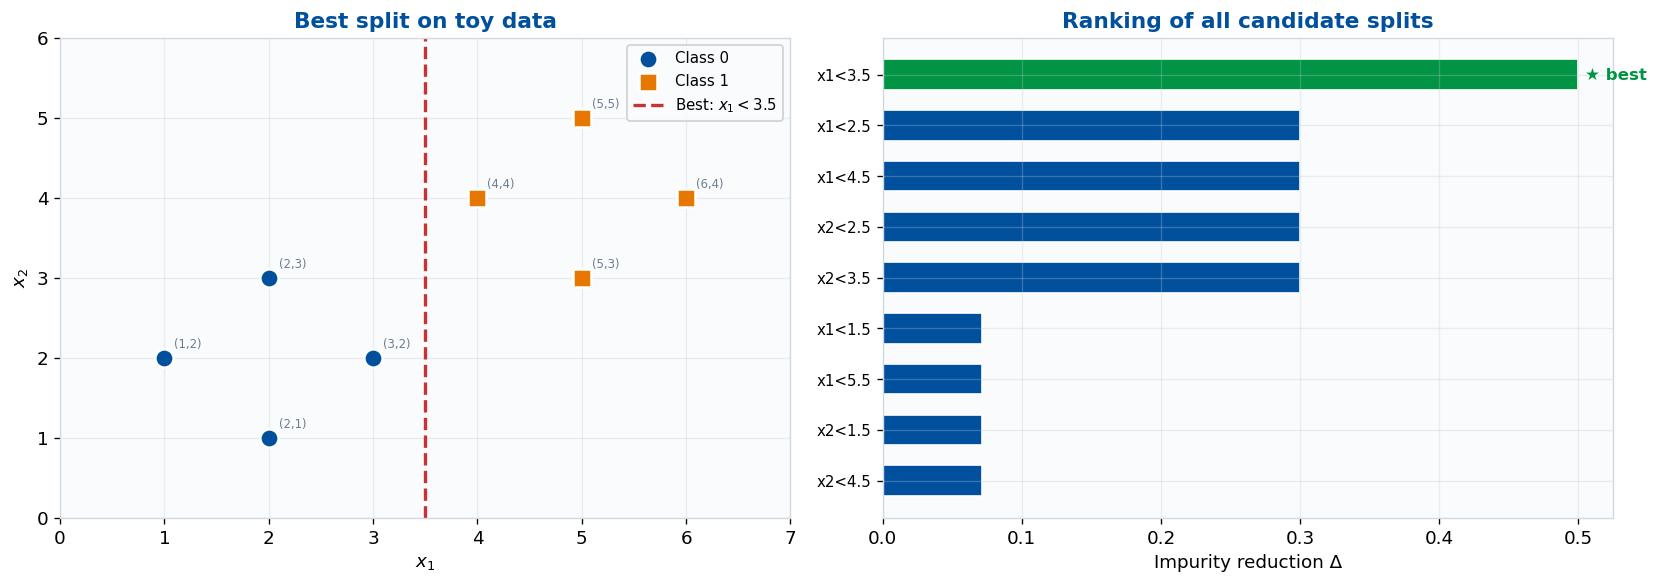

In [44]:
# ── Visualise all candidate splits with their impurity reduction ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: scatter + best split line
ax = axes[0]
for c, (label, color, marker) in enumerate([(0, NTNU['blue'], 'o'), (1, NTNU['orange'], 's')]):
    mask = data['y'] == label
    ax.scatter(data.loc[mask, 'x1'], data.loc[mask, 'x2'], 
              c=color, marker=marker, s=120, edgecolors='white', 
              linewidth=1.5, zorder=5, label=f'Class {label}')
    for _, row in data.loc[mask].iterrows():
        ax.annotate(f"({int(row['x1'])},{int(row['x2'])})", 
                    (row['x1'], row['x2']), fontsize=7,
                    textcoords="offset points", xytext=(6, 6), color=NTNU['gray'])

# Draw best split
best = df_splits.iloc[0]
if best['feature'] == 'x1':
    ax.axvline(best['threshold'], color=NTNU['red'], linewidth=2, linestyle='--',
               label=f"Best: $x_1 < {best['threshold']:.1f}$")
else:
    ax.axhline(best['threshold'], color=NTNU['red'], linewidth=2, linestyle='--',
               label=f"Best: $x_2 < {best['threshold']:.1f}$")

ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Best split on toy data', color=NTNU['blue'])
ax.legend(fontsize=9)
ax.set_xlim(0, 7); ax.set_ylim(0, 6)

# Right panel: bar chart of impurity reductions
ax = axes[1]
labels = [f"{r['feature']}<{r['threshold']:.1f}" for _, r in df_splits.iterrows()]
colors = [NTNU['green'] if r['delta'] == df_splits['delta'].max() else NTNU['blue'] 
          for _, r in df_splits.iterrows()]
bars = ax.barh(range(len(labels)), df_splits['delta'], color=colors, 
               edgecolor='white', height=0.6)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Impurity reduction Δ')
ax.set_title('Ranking of all candidate splits', color=NTNU['blue'])
ax.invert_yaxis()

# Annotate best
ax.barh(0, df_splits.iloc[0]['delta'], color=NTNU['green'], edgecolor='white', height=0.6)
ax.text(df_splits.iloc[0]['delta'] + 0.005, 0, '★ best', 
        va='center', fontsize=10, fontweight='bold', color=NTNU['green'])

plt.tight_layout()
plt.show()


---
## 5. Regression Trees: Variance Reduction

For regression, the impurity measure is the **within-node residual sum of squares (RSS)**:

$$\mathcal{I}(S) = \sum_{i \in S} (y_i - \bar{y}_S)^2$$

The tree predicts the **mean** in each leaf. Let's see how a regression tree approximates a nonlinear function.


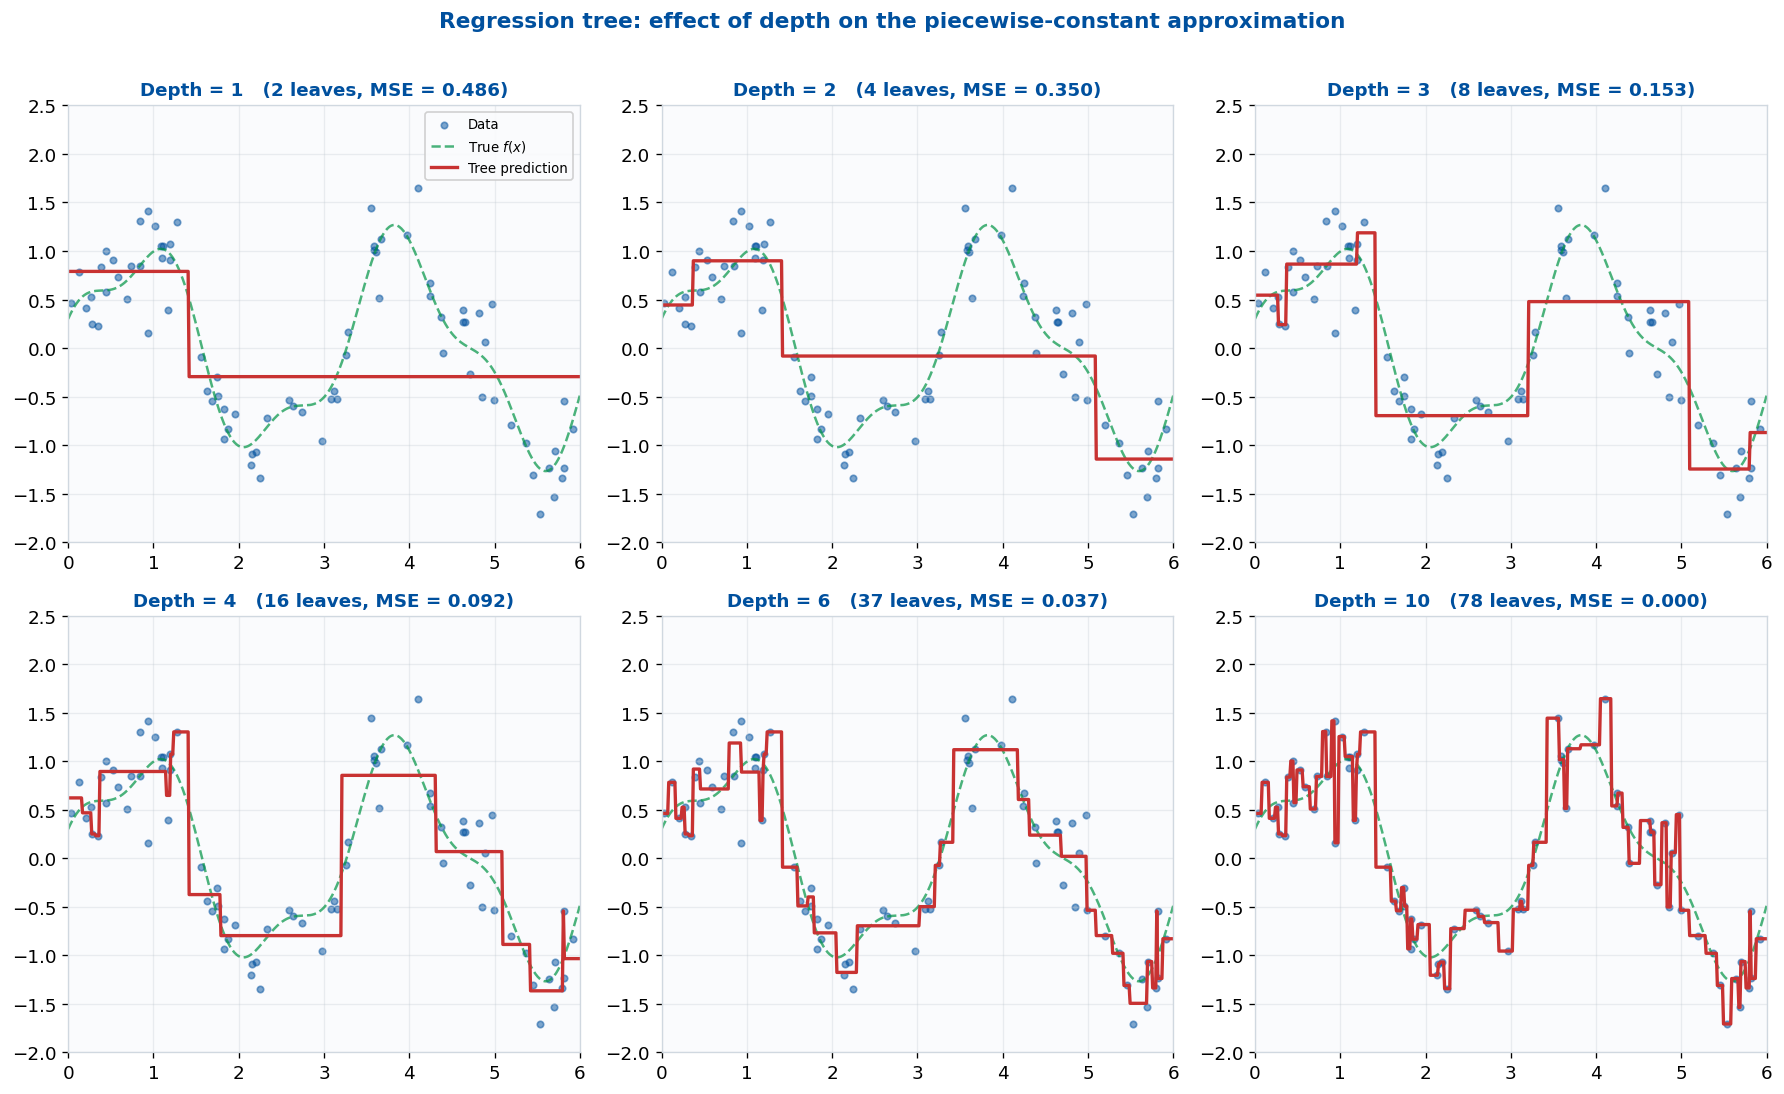

In [45]:
# ── 1D regression: true function + noisy samples ──
np.random.seed(42)
f_true = lambda x: np.sin(2*x) + 0.3*np.cos(5*x)

X_reg = np.sort(np.random.uniform(0, 6, 80))
y_reg = f_true(X_reg) + np.random.normal(0, 0.3, 80)
X_reg_2d = X_reg.reshape(-1, 1)
x_grid = np.linspace(0, 6, 500).reshape(-1, 1)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

depths = [1, 2, 3, 4, 6, 10]
for ax, d in zip(axes.ravel(), depths):
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_reg_2d, y_reg)
    y_pred = tree.predict(x_grid)
    
    train_mse = mean_squared_error(y_reg, tree.predict(X_reg_2d))
    n_leaves = tree.get_n_leaves()
    
    ax.scatter(X_reg, y_reg, c=NTNU['blue'], s=15, alpha=0.5, label='Data')
    ax.plot(x_grid, f_true(x_grid.ravel()), color=NTNU['green'], 
            linewidth=1.5, linestyle='--', label='True $f(x)$', alpha=0.7)
    ax.plot(x_grid, y_pred, color=NTNU['red'], linewidth=2, label='Tree prediction')
    ax.set_title(f'Depth = {d}   ({n_leaves} leaves, MSE = {train_mse:.3f})', 
                 color=NTNU['blue'], fontsize=11)
    ax.set_xlim(0, 6); ax.set_ylim(-2, 2.5)
    if d == 1:
        ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Regression tree: effect of depth on the piecewise-constant approximation',
             fontsize=13, fontweight='bold', color=NTNU['blue'], y=1.01)
plt.tight_layout()
plt.show()


**Observations:**
- At **depth 1** (a stump), the tree has only 2 leaves — very high bias.
- At **depth 3–4**, the tree captures the main oscillations of the true function.
- At **depth 10**, the tree has enough leaves to fit individual noise points — overfitting.
- The prediction is always a **staircase** (piecewise constant), which makes trees rough approximators for smooth functions.


---
## 6. Bias–Variance Tradeoff: A Simulation

To truly understand the bias–variance tradeoff, we'll generate **many datasets** from the same process and examine how tree predictions vary.


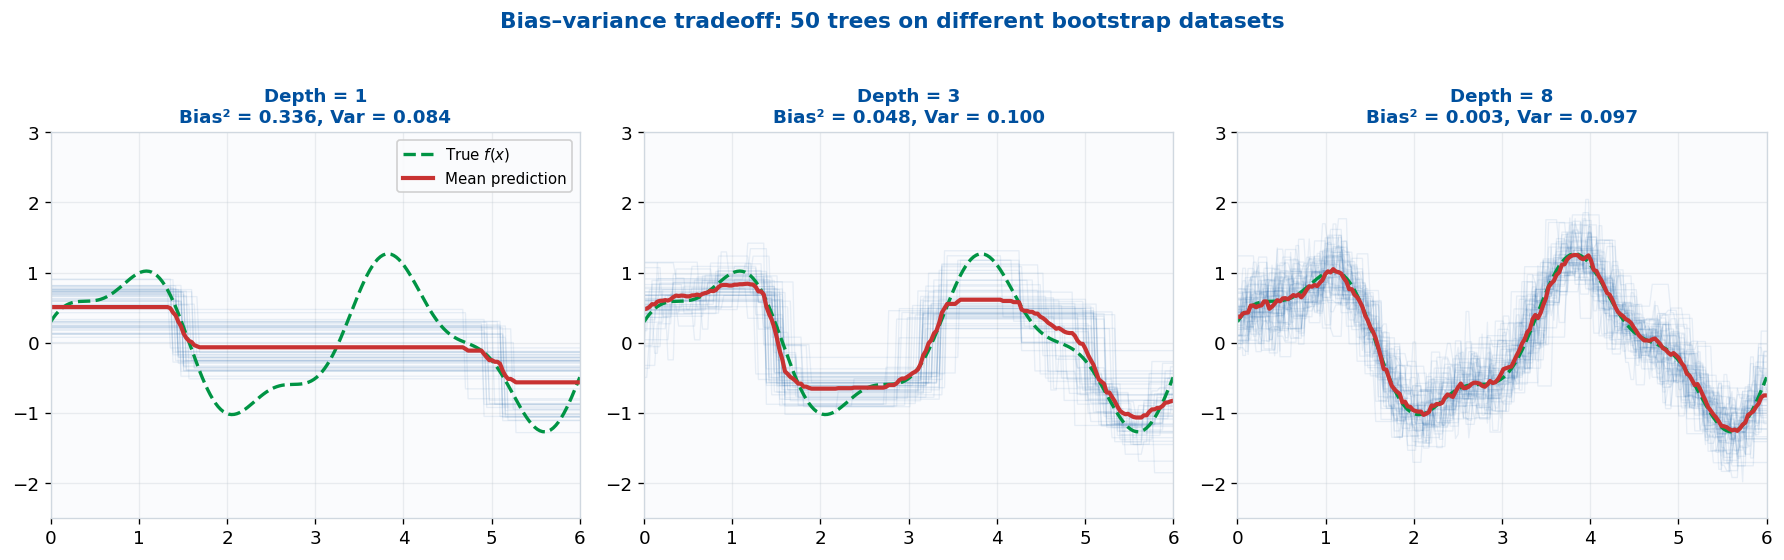

In [46]:
np.random.seed(0)
n_datasets = 50
depths_to_try = [1, 3, 8]
x_test = np.linspace(0, 6, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, d in zip(axes, depths_to_try):
    all_preds = []
    for i in range(n_datasets):
        X_i = np.sort(np.random.uniform(0, 6, 60)).reshape(-1, 1)
        y_i = f_true(X_i.ravel()) + np.random.normal(0, 0.3, 60)
        tree = DecisionTreeRegressor(max_depth=d, random_state=i)
        tree.fit(X_i, y_i)
        pred = tree.predict(x_test)
        all_preds.append(pred)
        ax.plot(x_test, pred, color=NTNU['blue'], alpha=0.08, linewidth=0.8)
    
    all_preds = np.array(all_preds)
    mean_pred = all_preds.mean(axis=0)
    
    ax.plot(x_test, f_true(x_test.ravel()), color=NTNU['green'], 
            linewidth=2, linestyle='--', label='True $f(x)$')
    ax.plot(x_test, mean_pred, color=NTNU['red'], linewidth=2.5, label='Mean prediction')
    
    # Compute bias² and variance at test points
    bias2 = np.mean((mean_pred - f_true(x_test.ravel()))**2)
    variance = np.mean(all_preds.var(axis=0))
    
    ax.set_title(f'Depth = {d}\nBias² = {bias2:.3f}, Var = {variance:.3f}', 
                 color=NTNU['blue'], fontsize=11)
    ax.set_xlim(0, 6); ax.set_ylim(-2.5, 3)
    if d == 1:
        ax.legend(fontsize=9, loc='upper right')

plt.suptitle('Bias–variance tradeoff: 50 trees on different bootstrap datasets',
             fontsize=13, fontweight='bold', color=NTNU['blue'], y=1.03)
plt.tight_layout()
plt.show()


**Key insight:**
- **Depth 1:** All 50 trees look similar (low variance) but they all miss the true shape (high bias). The mean prediction is a poor fit.
- **Depth 3:** A good balance — moderate spread, decent approximation of the true function.
- **Depth 8:** Each tree looks very different (high variance), but the mean is actually reasonable. This is the motivation for **ensemble methods** — if we average many high-variance trees, we get a better estimator.


---
## 7. Train vs. Test Error: Finding the Right Depth

Let's use cross-validation to find the optimal tree depth.


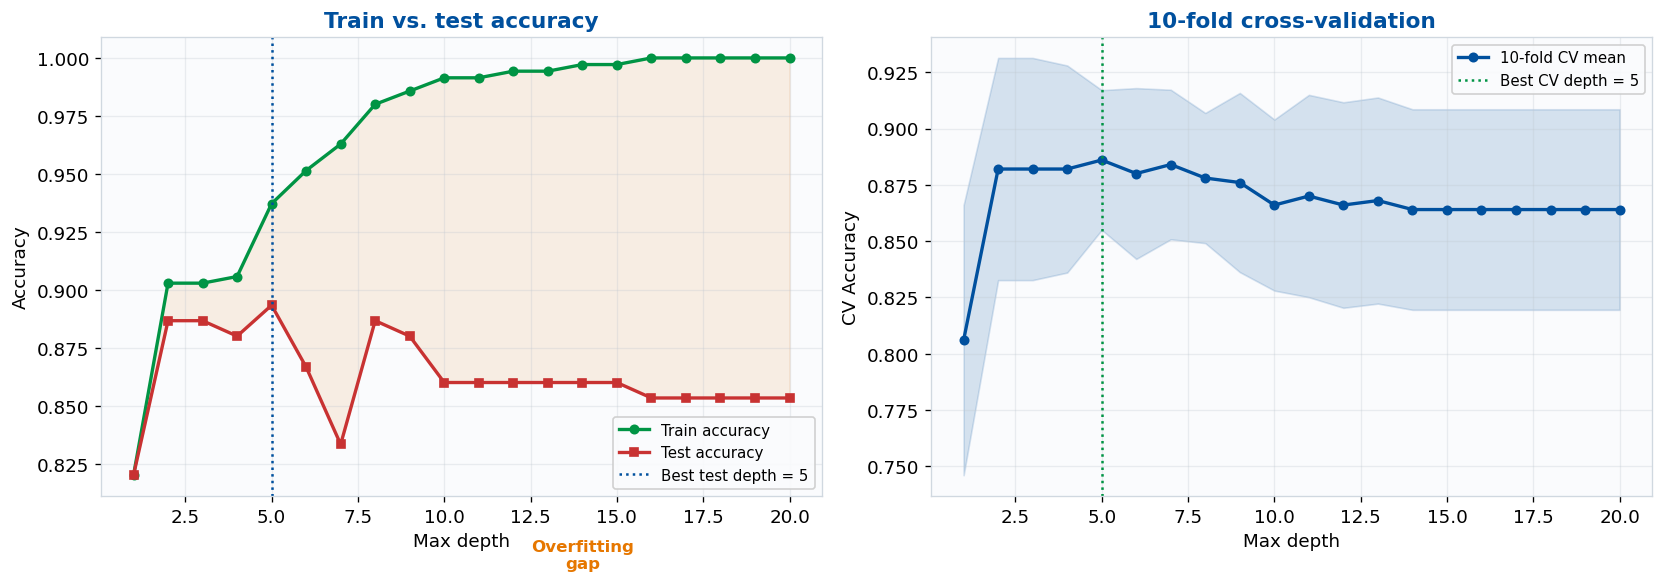

Best depth by test set: 5 (accuracy = 0.893)
Best depth by 10-fold CV: 5 (accuracy = 0.886)


In [47]:
# ── Make Moons dataset for a more interesting boundary ──
X_moon, y_moon = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_moon, y_moon, 
                                                      test_size=0.3, random_state=42)

depths = range(1, 21)
train_scores = []
test_scores = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

# Also get CV scores
cv_mean = []
cv_std = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(clf, X_moon, y_moon, cv=10, scoring='accuracy')
    cv_mean.append(scores.mean())
    cv_std.append(scores.std())

cv_mean = np.array(cv_mean)
cv_std = np.array(cv_std)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: Train vs test accuracy ──
ax = axes[0]
ax.plot(depths, train_scores, 'o-', color=NTNU['green'], linewidth=2, markersize=5, label='Train accuracy')
ax.plot(depths, test_scores,  's-', color=NTNU['red'],   linewidth=2, markersize=5, label='Test accuracy')
ax.fill_between(depths, test_scores, train_scores, alpha=0.1, color=NTNU['orange'])
best_depth = depths[np.argmax(test_scores)]
ax.axvline(best_depth, color=NTNU['blue'], linewidth=1.5, linestyle=':', 
           label=f'Best test depth = {best_depth}')
ax.set_xlabel('Max depth')
ax.set_ylabel('Accuracy')
ax.set_title('Train vs. test accuracy', color=NTNU['blue'])
ax.legend(fontsize=9)
ax.text(14, 0.78, 'Overfitting\ngap', fontsize=10, color=NTNU['orange'], 
        ha='center', fontweight='bold')

# ── Panel 2: CV scores ──
ax = axes[1]
ax.plot(depths, cv_mean, 'o-', color=NTNU['blue'], linewidth=2, markersize=5, label='10-fold CV mean')
ax.fill_between(depths, cv_mean - cv_std, cv_mean + cv_std, alpha=0.15, color=NTNU['blue'])
best_cv = depths[np.argmax(cv_mean)]
ax.axvline(best_cv, color=NTNU['green'], linewidth=1.5, linestyle=':', 
           label=f'Best CV depth = {best_cv}')
ax.set_xlabel('Max depth')
ax.set_ylabel('CV Accuracy')
ax.set_title('10-fold cross-validation', color=NTNU['blue'])
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Best depth by test set: {best_depth} (accuracy = {max(test_scores):.3f})")
print(f"Best depth by 10-fold CV: {best_cv} (accuracy = {max(cv_mean):.3f})")


---
## 8. Cost-Complexity Pruning

Instead of limiting depth, CART grows a full tree and **prunes** it using a complexity parameter $\alpha$:

$$C_\alpha(\mathcal{T}) = \sum_{j=1}^{|\mathcal{T}|} \text{RSS}_j + \alpha \, |\mathcal{T}|$$

Scikit-learn exposes the full pruning path via `cost_complexity_pruning_path`.


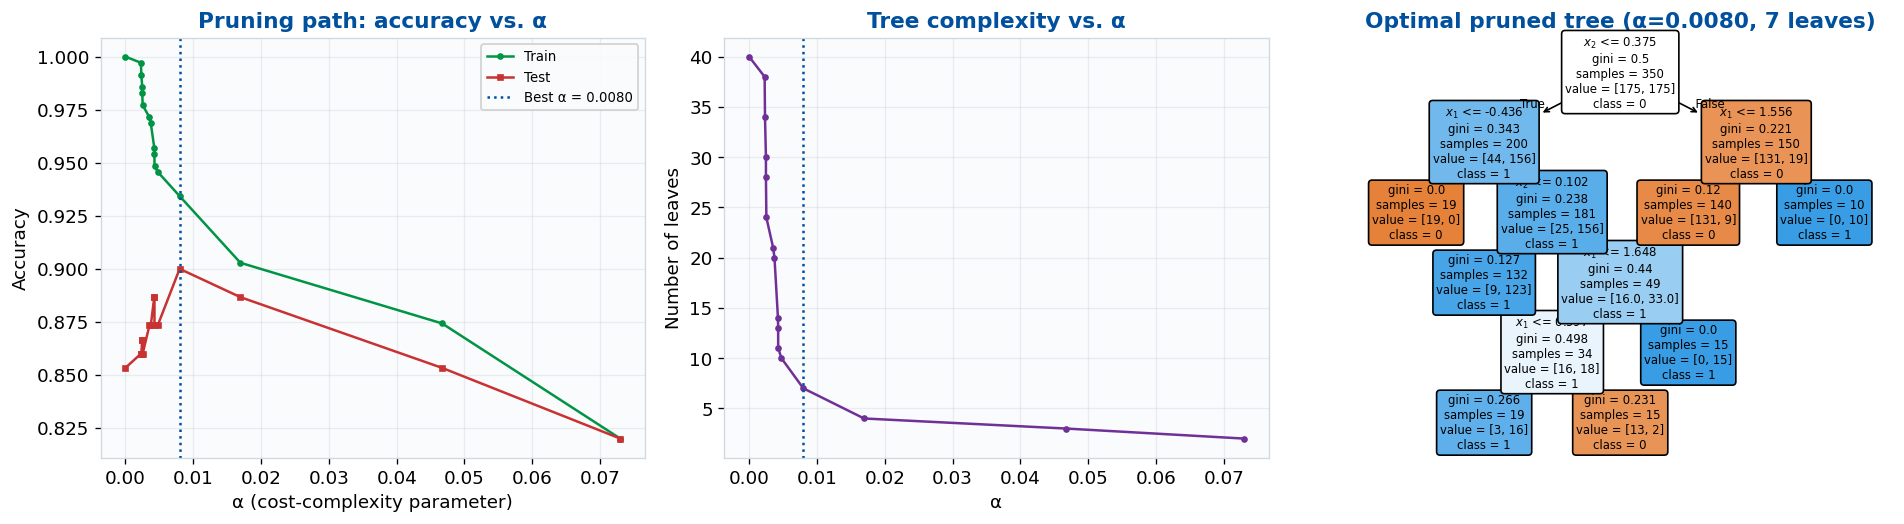


Full tree: 40 leaves, test accuracy = 0.853
Pruned tree: 7 leaves, test accuracy = 0.900


In [48]:
# ── Grow a full tree and get the pruning path ──
clf_full = DecisionTreeClassifier(random_state=42)
clf_full.fit(X_train, y_train)
path = clf_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # drop trivial root-only tree

# ── Train a tree for each alpha ──
train_acc = []
test_acc = []
n_leaves_list = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))
    n_leaves_list.append(clf.get_n_leaves())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── Panel 1: Accuracy vs alpha ──
ax = axes[0]
ax.plot(ccp_alphas, train_acc, 'o-', color=NTNU['green'], linewidth=1.5, markersize=3, label='Train')
ax.plot(ccp_alphas, test_acc,  's-', color=NTNU['red'],   linewidth=1.5, markersize=3, label='Test')
best_idx = np.argmax(test_acc)
ax.axvline(ccp_alphas[best_idx], color=NTNU['blue'], linewidth=1.5, linestyle=':', 
           label=f'Best α = {ccp_alphas[best_idx]:.4f}')
ax.set_xlabel('α (cost-complexity parameter)')
ax.set_ylabel('Accuracy')
ax.set_title('Pruning path: accuracy vs. α', color=NTNU['blue'])
ax.legend(fontsize=8)

# ── Panel 2: Number of leaves vs alpha ──
ax = axes[1]
ax.plot(ccp_alphas, n_leaves_list, 'o-', color=NTNU['purple'], linewidth=1.5, markersize=3)
ax.axvline(ccp_alphas[best_idx], color=NTNU['blue'], linewidth=1.5, linestyle=':')
ax.set_xlabel('α')
ax.set_ylabel('Number of leaves')
ax.set_title('Tree complexity vs. α', color=NTNU['blue'])

# ── Panel 3: Optimal pruned tree ──
ax = axes[2]
clf_pruned = DecisionTreeClassifier(ccp_alpha=ccp_alphas[best_idx], random_state=42)
clf_pruned.fit(X_train, y_train)
plot_tree(clf_pruned, filled=True, rounded=True, fontsize=7, ax=ax,
          feature_names=['$x_1$', '$x_2$'], class_names=['0', '1'])
ax.set_title(f'Optimal pruned tree (α={ccp_alphas[best_idx]:.4f}, '
             f'{clf_pruned.get_n_leaves()} leaves)', color=NTNU['blue'])

plt.tight_layout()
plt.show()

print(f"\nFull tree: {clf_full.get_n_leaves()} leaves, "
      f"test accuracy = {clf_full.score(X_test, y_test):.3f}")
print(f"Pruned tree: {clf_pruned.get_n_leaves()} leaves, "
      f"test accuracy = {clf_pruned.score(X_test, y_test):.3f}")


---
## 9. Instability of Decision Trees

A key limitation: small changes in data can produce **completely different tree structures**. Let's demonstrate this directly.


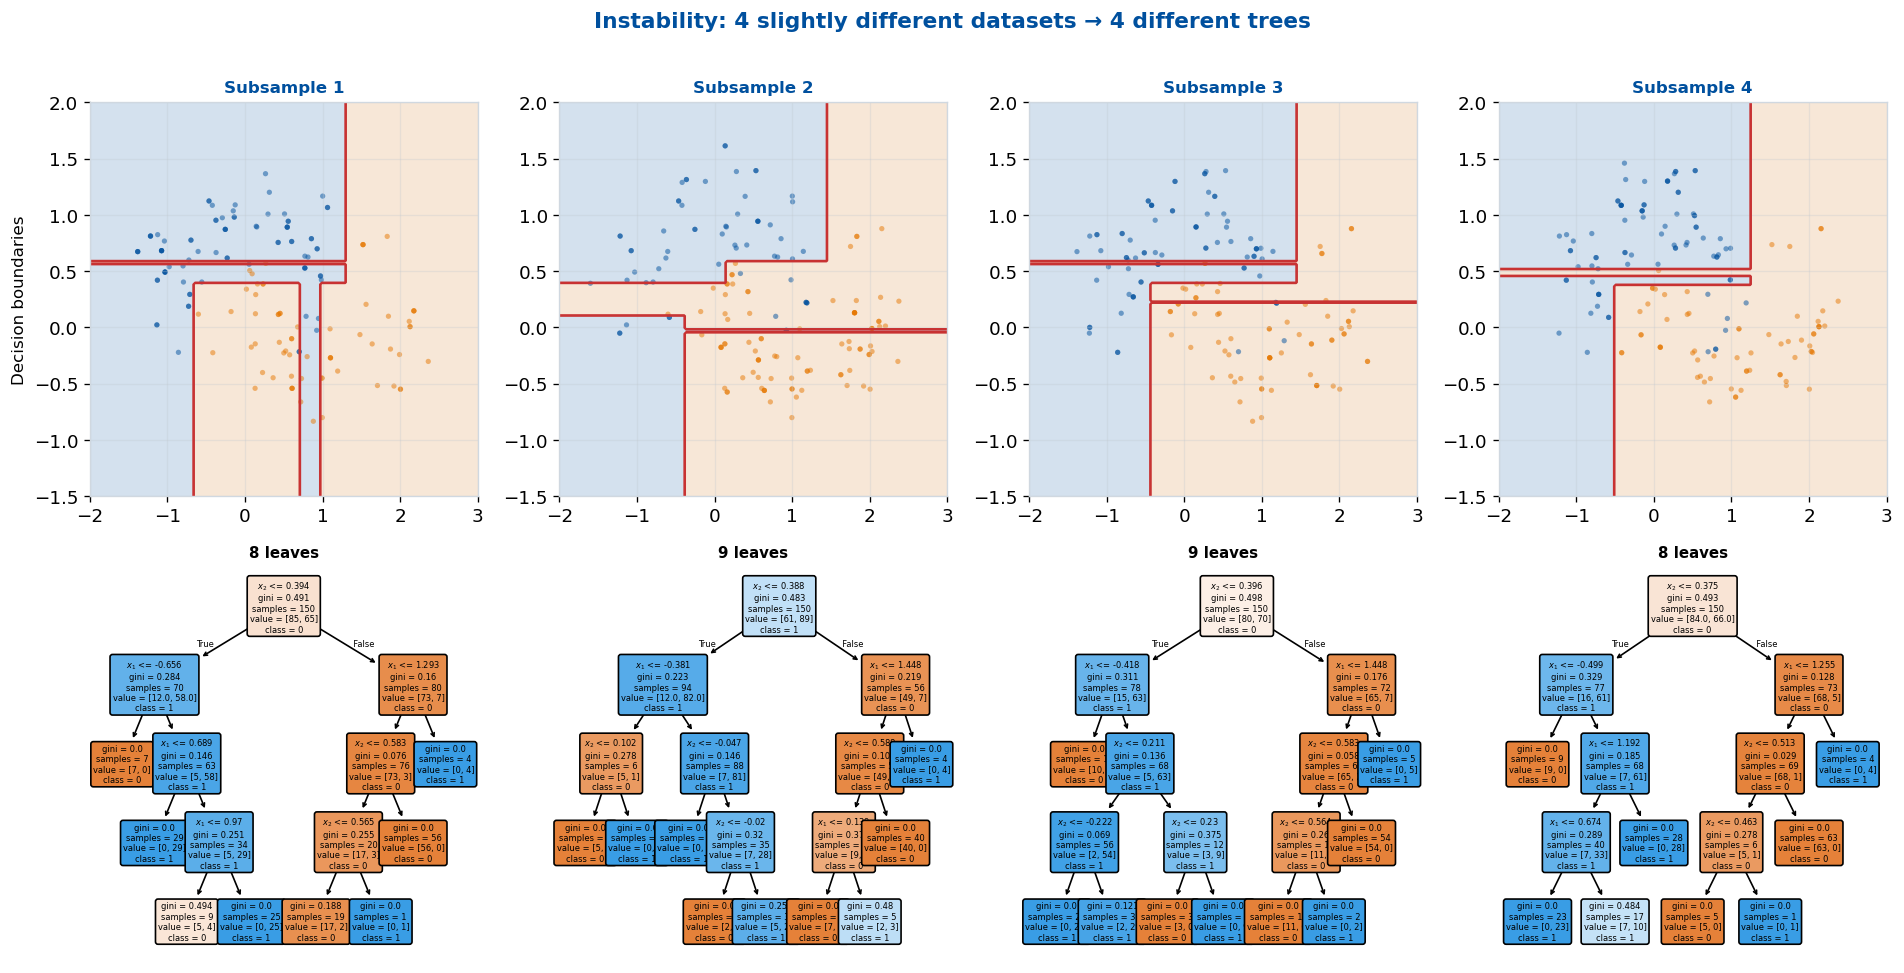

In [49]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

X_base, y_base = make_moons(n_samples=200, noise=0.25, random_state=42)

for i in range(4):
    # Subsample with different random seeds
    rng = np.random.RandomState(i * 7 + 3)
    idx = rng.choice(len(X_base), size=150, replace=True)
    X_sub, y_sub = X_base[idx], y_base[idx]
    
    clf = DecisionTreeClassifier(max_depth=4, random_state=42)
    clf.fit(X_sub, y_sub)
    
    # Decision boundary
    ax = axes[0, i]
    xx, yy = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.15, cmap=cmap_cls, levels=1)
    ax.contour(xx, yy, Z, colors=NTNU['red'], linewidths=1, levels=1)
    ax.scatter(X_sub[:, 0], X_sub[:, 1], c=y_sub, cmap=cmap_cls, s=10, alpha=0.5, edgecolors='none')
    ax.set_title(f'Subsample {i+1}', color=NTNU['blue'], fontsize=10)
    ax.set_xlim(-2, 3); ax.set_ylim(-1.5, 2)
    if i == 0:
        ax.set_ylabel('Decision boundaries', fontsize=10)
    
    # Tree structure
    ax = axes[1, i]
    plot_tree(clf, filled=True, rounded=True, fontsize=5, ax=ax,
              feature_names=['$x_1$', '$x_2$'], class_names=['0', '1'])
    ax.set_title(f'{clf.get_n_leaves()} leaves', fontsize=9)

plt.suptitle('Instability: 4 slightly different datasets → 4 different trees',
             fontsize=13, fontweight='bold', color=NTNU['blue'], y=1.01)
plt.tight_layout()
plt.show()


Each subsample produces a **different tree topology**. The root split, the number of leaves, and the boundary shapes all change. This **high variance** is the primary motivation for ensemble methods.


---
## 10. From Single Trees to Ensembles

### 10.1 Bagging: Variance Reduction by Averaging

If we train many trees on bootstrap samples and **average** their predictions, the variance drops:

$$\hat{f}_{\text{avg}}(\boldsymbol{x}) = \frac{1}{B}\sum_{b=1}^{B}\hat{f}^{(b)}(\boldsymbol{x})$$


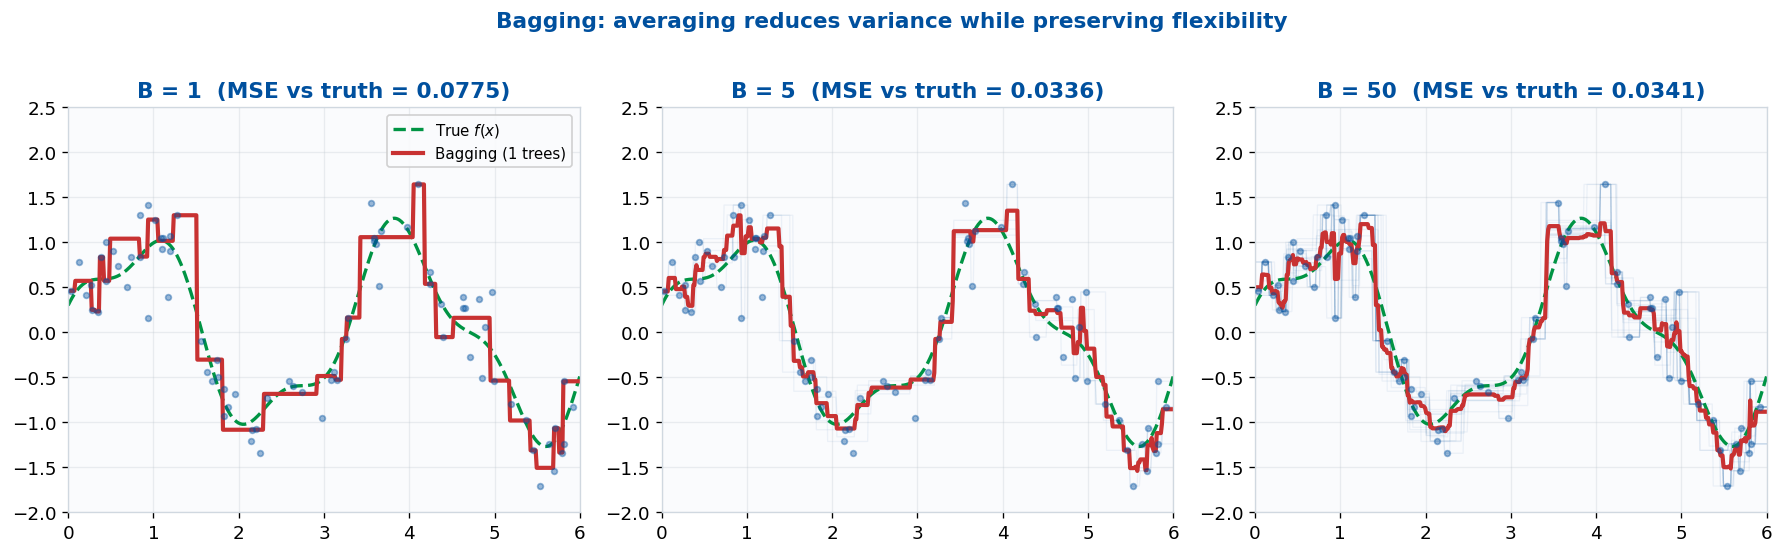

In [50]:
# ── Bagging on 1D regression ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
n_trees_list = [1, 5, 50]

for ax, B in zip(axes, n_trees_list):
    bag = BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=6),
        n_estimators=B, random_state=42, bootstrap=True
    )
    bag.fit(X_reg_2d, y_reg)
    
    # Plot individual trees
    for est in bag.estimators_[:min(B, 20)]:
        y_est = est.predict(x_grid)
        ax.plot(x_grid, y_est, color=NTNU['blue'], alpha=0.06, linewidth=0.8)
    
    # Plot ensemble prediction
    y_bag = bag.predict(x_grid)
    ax.plot(x_grid, f_true(x_grid.ravel()), color=NTNU['green'], 
            linewidth=2, linestyle='--', label='True $f(x)$')
    ax.plot(x_grid, y_bag, color=NTNU['red'], linewidth=2.5, label=f'Bagging ({B} trees)')
    ax.scatter(X_reg, y_reg, c=NTNU['blue'], s=12, alpha=0.4, zorder=5)
    
    mse = mean_squared_error(f_true(x_grid.ravel()), y_bag)
    ax.set_title(f'B = {B}  (MSE vs truth = {mse:.4f})', color=NTNU['blue'])
    ax.set_xlim(0, 6); ax.set_ylim(-2, 2.5)
    if B == 1:
        ax.legend(fontsize=9)

plt.suptitle('Bagging: averaging reduces variance while preserving flexibility',
             fontsize=13, fontweight='bold', color=NTNU['blue'], y=1.02)
plt.tight_layout()
plt.show()


### 10.2 Random Forest: Decorrelated Bagging

A random forest adds **feature subsampling** at each split, which **decorrelates** the trees and further reduces variance.


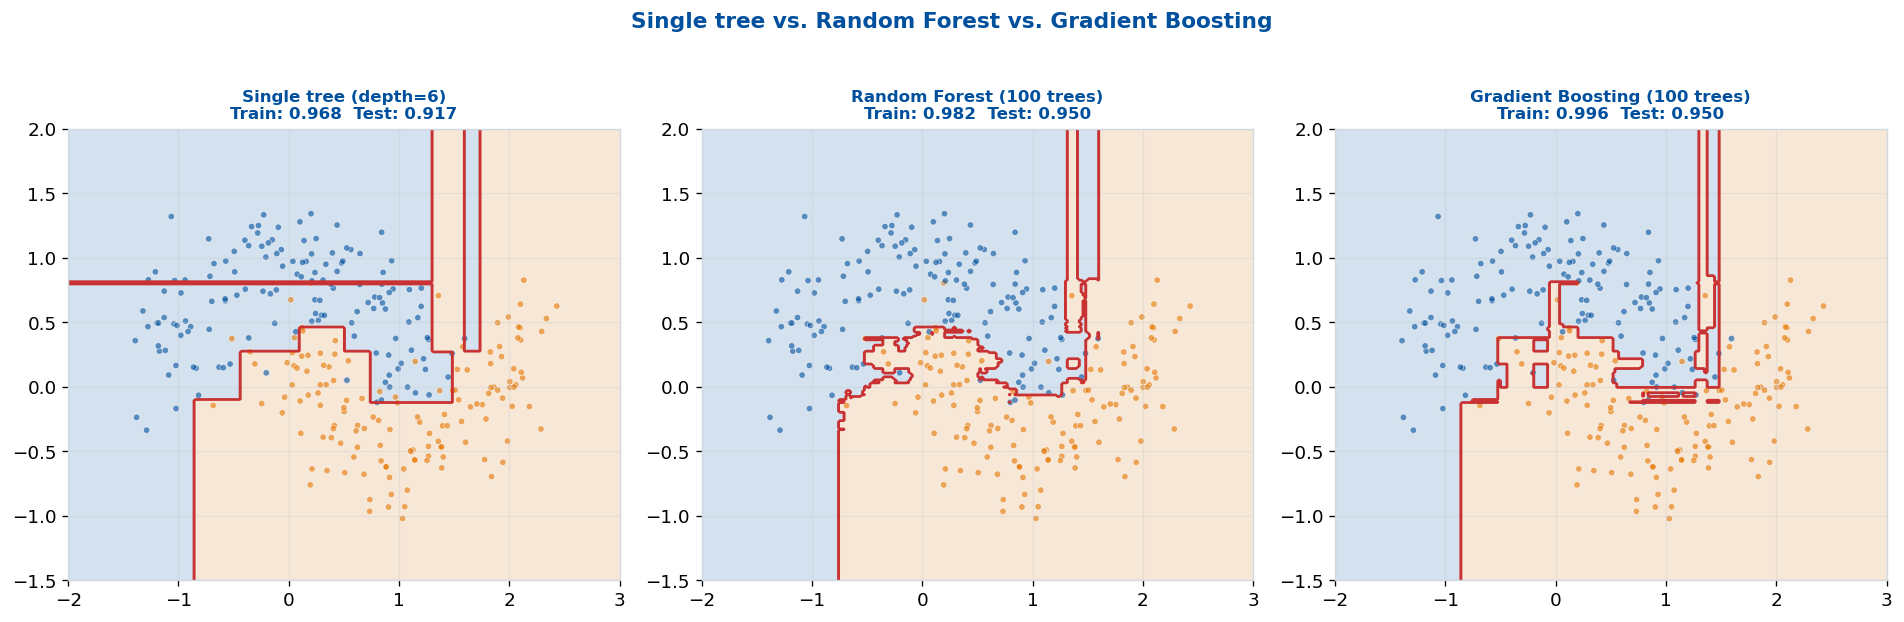

In [51]:
# ── Random Forest vs single tree on Make Moons ──
X_moon, y_moon = make_moons(n_samples=400, noise=0.25, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_moon, y_moon, test_size=0.3, random_state=42)

models = {
    'Single tree (depth=6)': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest (100 trees)': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    'Gradient Boosting (100 trees)': GradientBoostingClassifier(n_estimators=100, max_depth=3, 
                                                                  learning_rate=0.1, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
xx, yy = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-1.5, 2, 300))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_tr, y_tr)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.15, cmap=cmap_cls, levels=1)
    ax.contour(xx, yy, Z, colors=NTNU['red'], linewidths=1.2, levels=1)
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap=cmap_cls, s=15, 
              alpha=0.6, edgecolors='white', linewidth=0.5)
    
    train_acc = model.score(X_tr, y_tr)
    test_acc = model.score(X_te, y_te)
    ax.set_title(f'{name}\nTrain: {train_acc:.3f}  Test: {test_acc:.3f}', 
                 color=NTNU['blue'], fontsize=10)
    ax.set_xlim(-2, 3); ax.set_ylim(-1.5, 2)

plt.suptitle('Single tree vs. Random Forest vs. Gradient Boosting',
             fontsize=13, fontweight='bold', color=NTNU['blue'], y=1.03)
plt.tight_layout()
plt.show()


**Comparison:**

| Method | Mechanism | Strength |
|--------|-----------|----------|
| **Single tree** | One greedy tree | Interpretable but unstable |
| **Random Forest** | Parallel bagging + feature subsampling | Variance reduction |
| **Gradient Boosting** | Sequential residual fitting | Bias reduction |

Random forests smooth out the jagged single-tree boundary. Gradient boosting produces even smoother boundaries by sequentially correcting errors.


---
## 11. Feature Importance

Trees naturally provide a measure of feature importance: the **total reduction in impurity** (Gini or RSS) contributed by each feature across all splits.


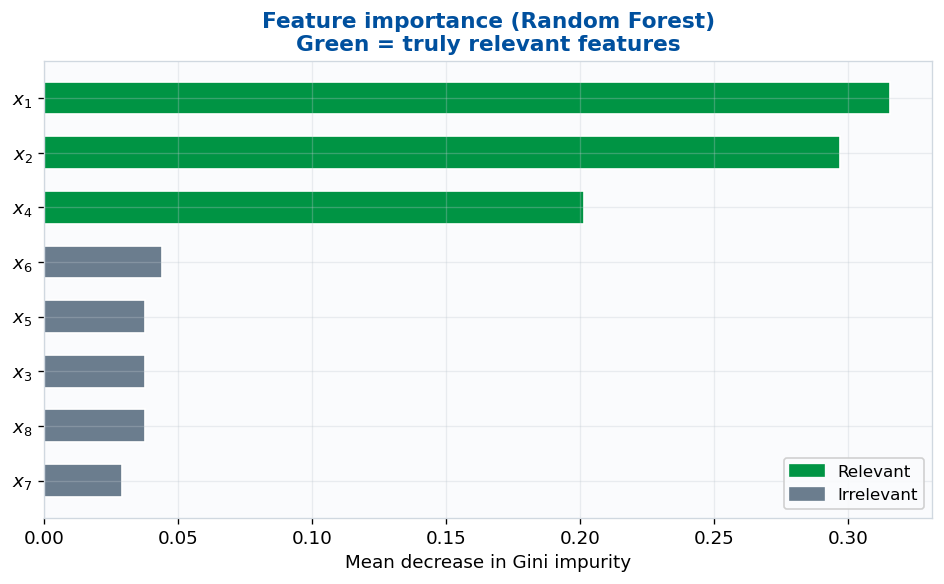

In [52]:
# ── Synthetic dataset with known relevant / irrelevant features ──
np.random.seed(42)
m = 500
X_fi = np.random.randn(m, 8)
# Only features 0, 1, 3 are relevant
y_fi = ((X_fi[:, 0] > 0) & (X_fi[:, 1] + X_fi[:, 3] > 0.5)).astype(int)
feat_names = [f'$x_{{{i+1}}}$' for i in range(8)]
relevant = {0, 1, 3}

rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_fi, y_fi)

importances = rf.feature_importances_
idx_sorted = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [NTNU['green'] if i in relevant else NTNU['gray'] for i in idx_sorted]
ax.barh(range(8), importances[idx_sorted], color=colors, edgecolor='white', height=0.6)
ax.set_yticks(range(8))
ax.set_yticklabels([feat_names[i] for i in idx_sorted])
ax.set_xlabel('Mean decrease in Gini impurity')
ax.set_title('Feature importance (Random Forest)\nGreen = truly relevant features', 
             color=NTNU['blue'])

# Add legend
ax.legend(handles=[
    mpatches.Patch(color=NTNU['green'], label='Relevant'),
    mpatches.Patch(color=NTNU['gray'], label='Irrelevant'),
], loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()


The forest correctly identifies $x_1$, $x_2$, and $x_4$ as the important features (they are the ones used to generate the labels). The irrelevant features ($x_3, x_5, \ldots, x_8$) have near-zero importance.

> **Caveat:** Impurity-based importance can be biased towards high-cardinality features. For a more robust measure, consider **permutation importance**.


---
## 12. Gradient Boosting: Sequential Residual Fitting

Boosting builds an additive model by fitting each new tree to the **residuals** of the current ensemble:

$$\hat{f}_M(\boldsymbol{x}) = \sum_{l=1}^{M} \nu \cdot h_l(\boldsymbol{x})$$

where $\nu$ is the learning rate and $h_l$ is a shallow tree. Let's watch this happen step by step.


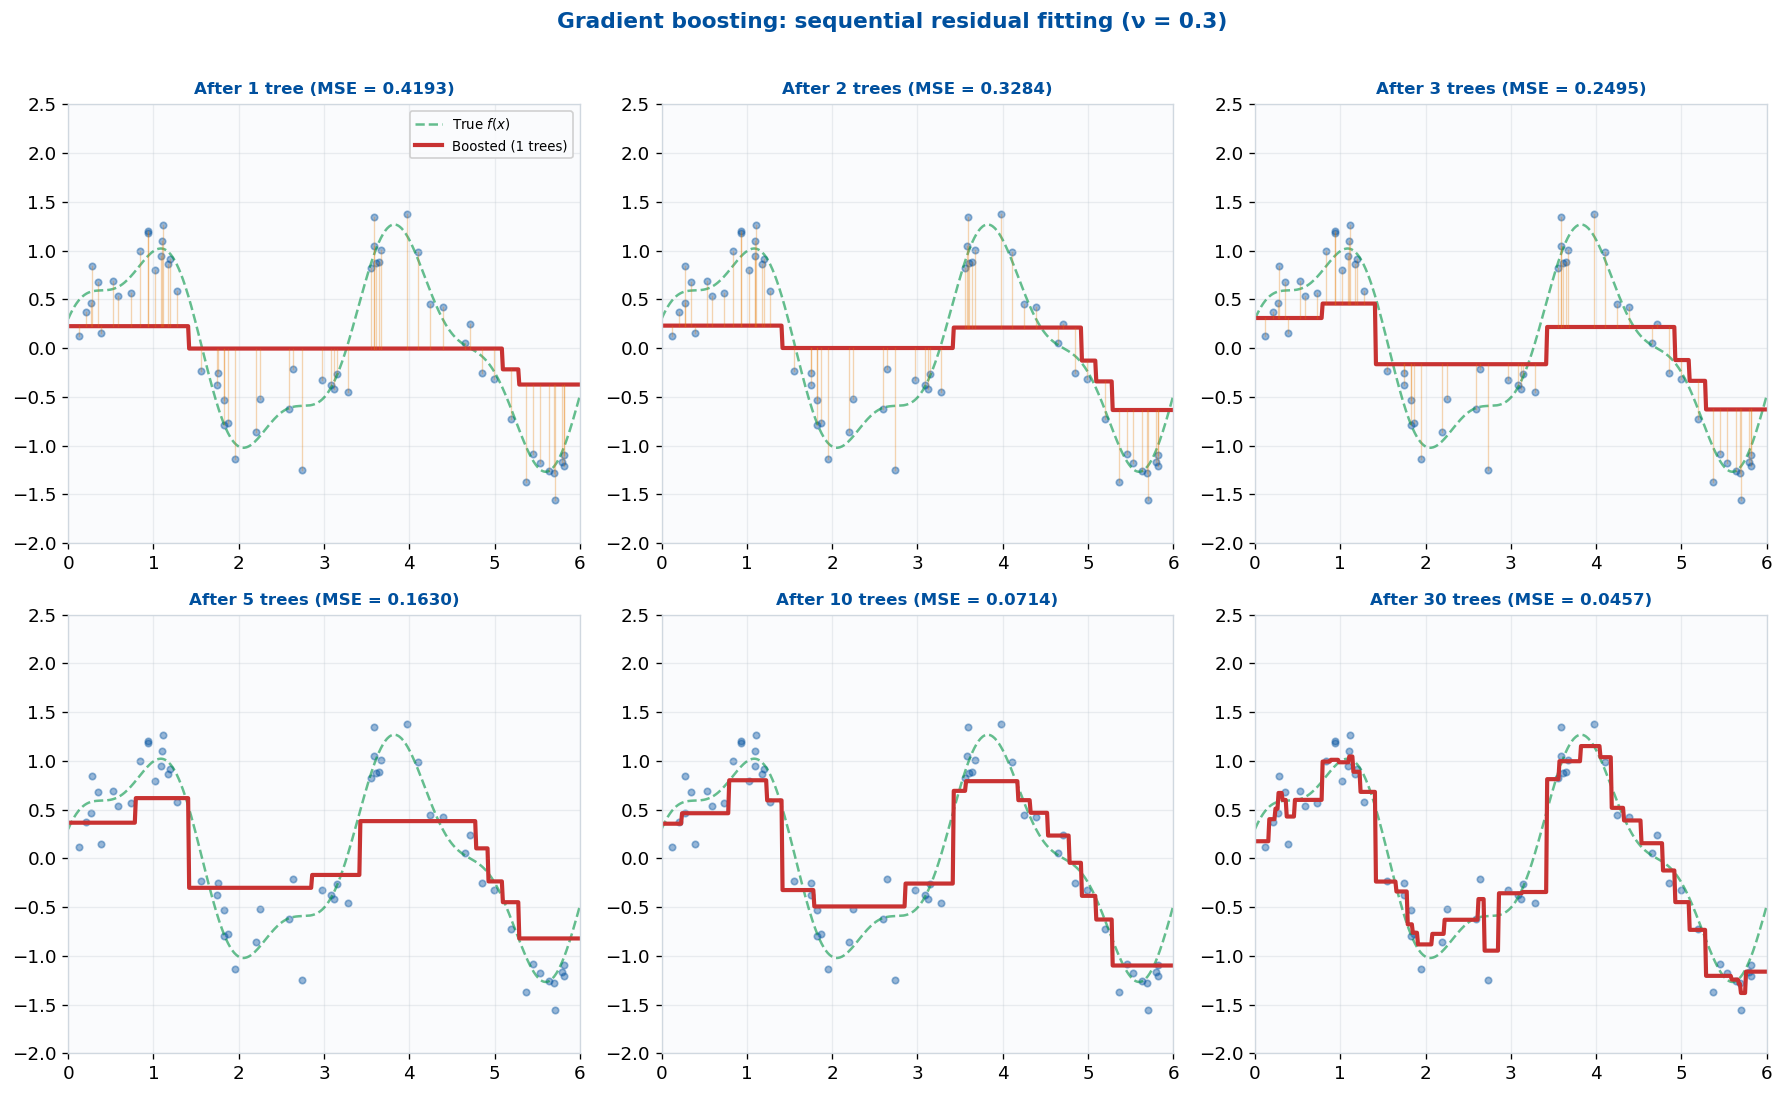

In [53]:
# ── Step-by-step boosting on 1D data ──
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X_b = np.sort(np.random.uniform(0, 6, 60)).reshape(-1, 1)
y_b = f_true(X_b.ravel()) + np.random.normal(0, 0.25, 60)
x_grid_b = np.linspace(0, 6, 500).reshape(-1, 1)

nu = 0.3  # learning rate
stages = [1, 2, 3, 5, 10, 30]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

f_current = np.zeros(len(X_b))
f_current_grid = np.zeros(len(x_grid_b))

stage_idx = 0
for m_iter in range(1, max(stages) + 1):
    residuals = y_b - f_current
    h = DecisionTreeRegressor(max_depth=2, random_state=m_iter)
    h.fit(X_b, residuals)
    
    f_current += nu * h.predict(X_b)
    f_current_grid += nu * h.predict(x_grid_b)
    
    if m_iter in stages:
        ax = axes.ravel()[stage_idx]
        
        # Current prediction
        ax.scatter(X_b.ravel(), y_b, c=NTNU['blue'], s=15, alpha=0.4)
        ax.plot(x_grid_b, f_true(x_grid_b.ravel()), color=NTNU['green'], 
                linewidth=1.5, linestyle='--', alpha=0.6, label='True $f(x)$')
        ax.plot(x_grid_b, f_current_grid, color=NTNU['red'], linewidth=2.5, 
                label=f'Boosted ({m_iter} trees)')
        
        # Show residuals as stems for early stages
        if m_iter <= 3:
            res_grid = y_b - f_current
            for xi, yi, ri in zip(X_b.ravel(), f_current, res_grid):
                ax.plot([xi, xi], [yi, yi + ri], color=NTNU['orange'], 
                        alpha=0.3, linewidth=0.8)
        
        mse = mean_squared_error(f_true(x_grid_b.ravel()), f_current_grid)
        ax.set_title(f'After {m_iter} tree{"s" if m_iter>1 else ""} (MSE = {mse:.4f})', 
                     color=NTNU['blue'], fontsize=10)
        ax.set_xlim(0, 6); ax.set_ylim(-2, 2.5)
        if stage_idx == 0:
            ax.legend(fontsize=8)
        stage_idx += 1

plt.suptitle(f'Gradient boosting: sequential residual fitting (ν = {nu})',
             fontsize=13, fontweight='bold', color=NTNU['blue'], y=1.01)
plt.tight_layout()
plt.show()


**How boosting works, visually:**

1. **Iteration 1:** Fit a shallow tree to the data. The orange vertical lines show residuals — what's left to explain.
2. **Iterations 2–3:** Each new tree focuses on the remaining residuals. The red curve gets closer to the green truth.
3. **Iterations 5–30:** The ensemble converges towards the true function. Note that each tree is only depth-2 (a stump with 4 leaves), yet their **sum** can represent complex functions.

The key difference from random forests: boosting reduces **bias** sequentially, whereas bagging reduces **variance** in parallel.


---
## 13. Comprehensive Model Comparison

Let's run a fair comparison of all tree-based methods on a dataset with a nonlinear boundary.


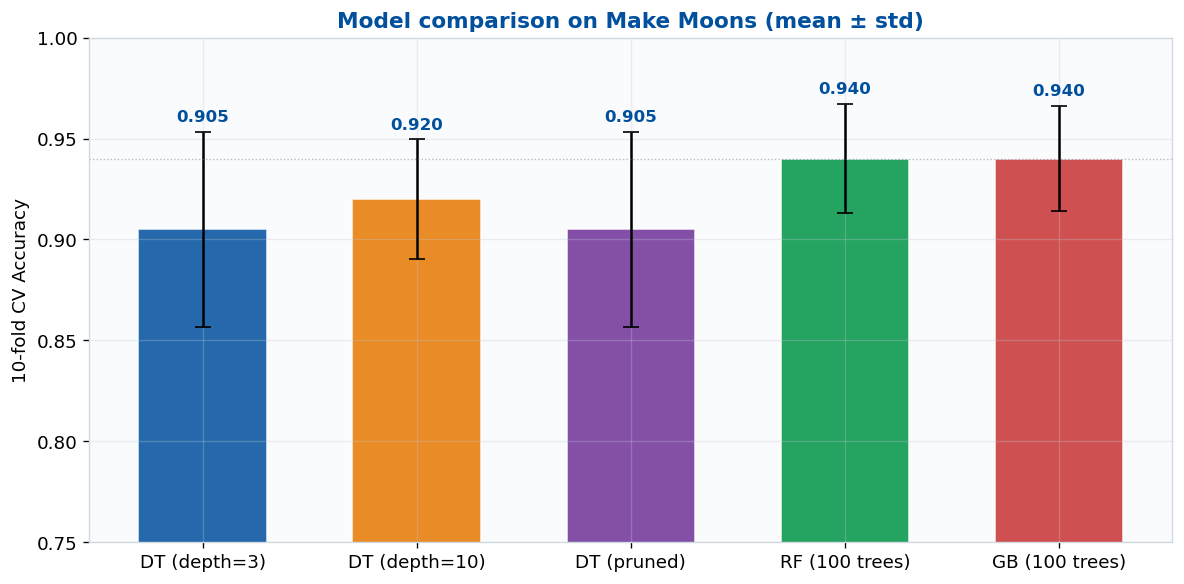

── 10-fold CV results ──
  DT (depth=3)          0.905 ± 0.048
  DT (depth=10)         0.920 ± 0.030
  DT (pruned)           0.905 ± 0.048
  RF (100 trees)        0.940 ± 0.027
  GB (100 trees)        0.940 ± 0.026


In [54]:
from sklearn.model_selection import cross_val_score

X_cmp, y_cmp = make_moons(n_samples=600, noise=0.25, random_state=42)

models_cmp = {
    'DT (depth=3)':   DecisionTreeClassifier(max_depth=3, random_state=42),
    'DT (depth=10)':  DecisionTreeClassifier(max_depth=10, random_state=42),
    'DT (pruned)':    DecisionTreeClassifier(ccp_alpha=0.02, random_state=42),
    'RF (100 trees)': RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
    'GB (100 trees)': GradientBoostingClassifier(n_estimators=100, max_depth=3, 
                                                   learning_rate=0.1, random_state=42),
}

results = {}
for name, model in models_cmp.items():
    scores = cross_val_score(model, X_cmp, y_cmp, cv=10, scoring='accuracy')
    results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}

# ── Bar chart ──
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
means = [results[n]['mean'] for n in names]
stds  = [results[n]['std'] for n in names]
colors = [NTNU['blue'], NTNU['orange'], NTNU['purple'], NTNU['green'], NTNU['red']]

bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors, 
              edgecolor='white', width=0.6, alpha=0.85)

# Annotate
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.005,
            f'{m:.3f}', ha='center', fontsize=10, fontweight='bold', color=NTNU['blue'])

ax.set_ylabel('10-fold CV Accuracy')
ax.set_title('Model comparison on Make Moons (mean ± std)', color=NTNU['blue'])
ax.set_ylim(0.75, 1.0)
ax.axhline(max(means), color=NTNU['gray'], linewidth=0.8, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("── 10-fold CV results ──")
for name in names:
    r = results[name]
    print(f"  {name:20s}  {r['mean']:.3f} ± {r['std']:.3f}")


---
## Summary

| Concept | Key takeaway |
|---------|-------------|
| **Tree structure** | Recursive partitions of feature space into hyperrectangles |
| **Split criteria** | Gini and entropy preferred over misclassification error for greedy splitting |
| **Regression trees** | Minimise within-node RSS; predict the leaf mean |
| **Bias–variance** | Deep trees = low bias, high variance; shallow = opposite |
| **Pruning** | Cost-complexity pruning trades training fit for simplicity via $\alpha$ |
| **Instability** | Small data changes → different trees. Key motivation for ensembles |
| **Random Forest** | Bagging + feature subsampling → variance reduction |
| **Gradient Boosting** | Sequential residual fitting → bias reduction |

### Further Reading
- Hastie, Tibshirani, Friedman — *The Elements of Statistical Learning*, Ch. 9–10
- Breiman et al. — *Classification and Regression Trees*
- James, Witten, Hastie, Tibshirani — *An Introduction to Statistical Learning*, Ch. 8

---
*TTK4260 — Department of Engineering Cybernetics, NTNU*
